In [2]:
import networkx as nx
from networkx.readwrite import json_graph
from gerrychain import Graph
import matplotlib.pyplot as plt
import requests
import json
import maup
import geopandas as gpd

In [13]:
alarm = gpd.read_file("./FL_ALARM/fl_alarm.shp")

<Axes: >

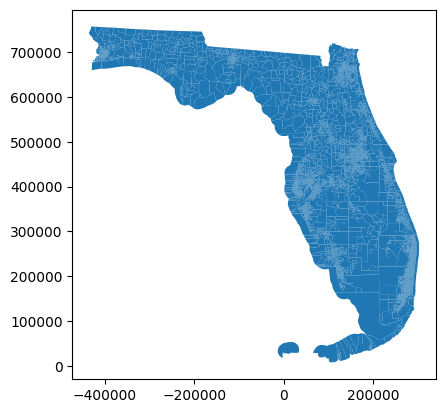

In [14]:
alarm.plot()

In [15]:
CON = gpd.read_file("./fl_cong_adopted_2022/P000C0109.shp")
SLDU = gpd.read_file("./fl_sldu_adopted_2022/S027S8058.shp")
SLDL = gpd.read_file("./fl_sldl_adopted_2022/H000H8013.shp")

In [16]:
CON = CON.to_crs(alarm.crs)
SLDU = SLDU.to_crs(alarm.crs)
SLDL = SLDL.to_crs(alarm.crs)


bk_to_CON = maup.assign(alarm,CON)
bk_to_SLDU = maup.assign(alarm,SLDU.to_crs(alarm.crs))
bk_to_SLDL = maup.assign(alarm,SLDL.to_crs(alarm.crs))

In [17]:
alarm["CON"] = bk_to_CON
alarm["SLDU"] = bk_to_SLDU
alarm["SLDL"] = bk_to_SLDL

(-472027.96975924, 338881.00315303996, -30211.021659995, 794695.726609895)

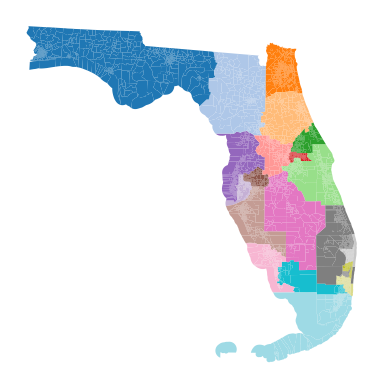

In [8]:
alarm.plot(column="CON",cmap='tab20')
plt.axis('off')

In [18]:
alarm['C_X'] = alarm.centroid.x
alarm['C_Y'] = alarm.centroid.y

In [ ]:
precinct_graph = Graph.from_geodataframe(alarm)


alarm.to_file("./output/FL_Processed_Precincts_ALARM.shp")

precinct_graph.to_json("./output/FL_Processed_Precincts_ALARM.json")

GeometryError: Invalid geometries at rows [252] before reprojection. Consider repairing the affected geometries with `.buffer(0)`, or pass `ignore_errors=True` to attempt to create the graph anyways.

In [22]:
precinct_graph.nodes()[252]

{'boundary_node': False,
 'area': 1554476.1214920562,
 'GEOID': '12009000410',
 'state': 'FL',
 'county': 'Brevard County',
 'muni': '54425',
 'cnty_mn': 'Brevard County54425',
 'cd_2010': 8,
 'cd_2020': 8,
 'vtd': '000410',
 'pop': 1188.0,
 'pop_hsp': 123.0,
 'pop_wht': 891.0,
 'pp_blck': 50.0,
 'pop_ain': 2.0,
 'pop_asn': 45.0,
 'pop_nhp': 2.0,
 'pop_thr': 9.0,
 'pop_two': 66.0,
 'vap': 989.0,
 'vap_hsp': 81.0,
 'vap_wht': 770.0,
 'vp_blck': 43.0,
 'vap_ain': 2.0,
 'vap_asn': 40.0,
 'vap_nhp': 2.0,
 'vap_thr': 7.0,
 'vap_two': 44.0,
 'pr_16_r_': 395.7,
 'pr_16_d_': 202.7,
 'uss_16_r_': 378.8,
 'uss_16_d_': 205.3,
 'uss_18_r_': 380.1,
 'uss_18_d_': 229.3,
 'gv_18_r_': 389.6,
 'gv_18_d_': 208.3,
 'atg_18_r_': 401.2,
 'atg_18_d_': 179.6,
 'pr_20_r_': 446.3,
 'pr_20_d_': 283.1,
 'arv_16': 387.2,
 'adv_16': 204.0,
 'arv_18': 390.3,
 'adv_18': 205.7,
 'arv_20': 446.3,
 'adv_20': 283.1,
 'nrv': 398.6,
 'ndv': 218.1,
 'are_lnd': 1681394.0,
 'are_wtr': 0.0,
 'cvap': 738.5675652,
 'cvp_wht': 6

In [23]:
[precinct_graph.nodes[x]["GEOID"] for x in precinct_graph.neighbors(252)]

['12009000422', '12009000427', '12009000421', '12009000416']